In [40]:

# библиотеки
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import scipy.stats as sts
from itertools import combinations
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [41]:
# load data
%store -r data
pd.set_option('display.float_format', '{:.3f}'.format)
data2 = data

top_genres = ['Romance', 'Comedy', 'Hentai', 'Fantasy', 'Boys Love']
top_themes = ['School', 'Historical', 'Harem', 'Psychological', 'Isekai']
print(top_genres)
print(data['type'].unique())


['Romance', 'Comedy', 'Hentai', 'Fantasy', 'Boys Love']
['manga' 'manhua' 'manhwa' 'doujinshi' 'light_novel' 'novel']


In [42]:
filter_data_genre = {}
for genre in top_genres:
    data[f'is_{genre}'] = data['genres'].apply(lambda x: 1 if genre in x else 0)
    genre_yes = data[data[f'is_{genre}'] == 1]['score']
    genre_no = data[data[f'is_{genre}'] == 0]['score']
    _, pl = sts.levene(genre_yes, genre_no)
    _,pny = sts.shapiro(genre_yes)
    _,pnn = sts.shapiro(genre_no)
    filter_data_genre[genre] = [round(pl,3),round(pnn,3),round(pny,3)]
    print(f'{genre}:\nТест Левена: {pl:.3f}\np-value(да):{pny:.3f}\np-value(нет):{pnn:.3f}\n')


Romance:
Тест Левена: 0.813
p-value(да):0.000
p-value(нет):0.000

Comedy:
Тест Левена: 0.588
p-value(да):0.000
p-value(нет):0.000

Hentai:
Тест Левена: 0.001
p-value(да):0.000
p-value(нет):0.000

Fantasy:
Тест Левена: 0.518
p-value(да):0.000
p-value(нет):0.000

Boys Love:
Тест Левена: 0.001
p-value(да):0.064
p-value(нет):0.000



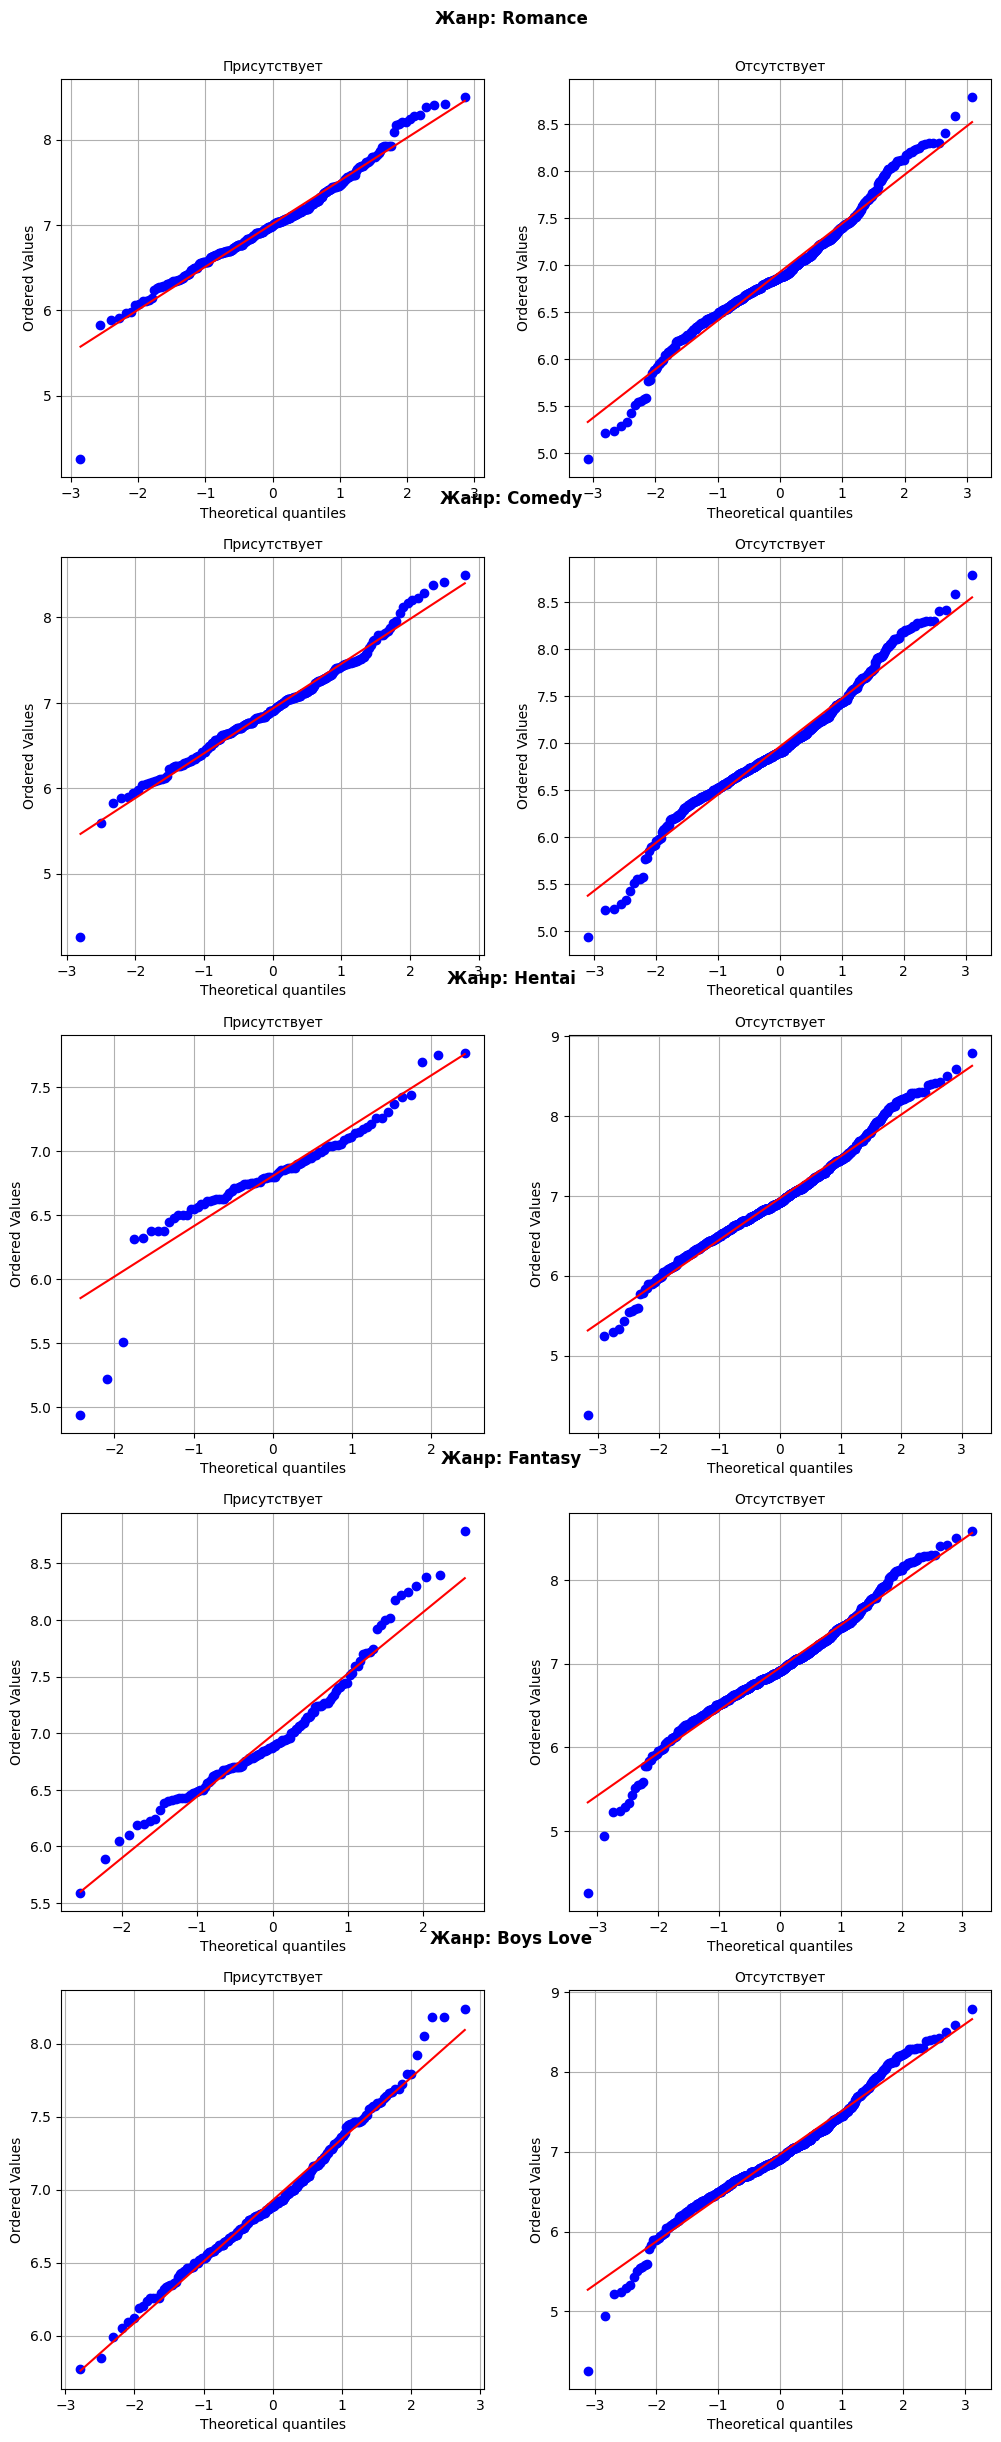

In [43]:
fig, axes = plt.subplots(len(top_genres), 2,figsize=(12, 6*len(top_genres))) 
for i in range(len(top_genres)):
    genre = top_genres[i]

    genre_yes = data[data[f'is_{genre}'] == 1]['score'].dropna()
    genre_no = data[data[f'is_{genre}'] == 0]['score'].dropna()

    sts.probplot(genre_yes, plot=axes[i, 0])  # Используем plot вместо ax
    sts.probplot(genre_no, plot=axes[i, 1])   # И индексацию [i,0] вместо [i][0]
    
    fig.text(
        x=0.5,  # Центрируем по горизонтали
        y=0.9 - i*0.8/len(top_genres),  # Позиционируем по вертикали
        s=f'Жанр: {genre}',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold'
    )
    
    # Подписи для подграфиков (опционально)
    axes[i, 0].set_title('Присутствует', fontsize=10)
    axes[i, 1].set_title('Отсутствует', fontsize=10)
    axes[i, 0].grid(True)
    axes[i, 1].grid(True)

In [44]:
mas = []
for genre in top_genres:
    arr = filter_data_genre[genre]
    if arr[0] > 0.005 and arr[1] > 0.05 and arr[2] > 0.05:
        mas.append(genre)
        genre_yes = data[data[f'is_{genre}'] == 1]['score'].dropna()
        genre_no = data[data[f'is_{genre}'] == 0]['score'].dropna()

        f_stat, p_value = sts.f_oneway(genre_yes, genre_no)
        f_critical = sts.f.ppf(0.95, 1, 48)
        
        formula = f'score ~ C(is_{genre})'
        model = ols(formula, data=data).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        

        sum_sq_0 = anova_table['sum_sq'][f'C(is_{genre})'] 
        sum_sq_1 = anova_table['sum_sq'][f'Residual']
        R2 = sum_sq_0/(sum_sq_0 + sum_sq_1)
        
        print(f'{genre}:\n F-факт:{f_stat:.3f}\n F-крит:{f_critical:.3f}\n P-value:{p_value:.3f}\n')
        print(f'R^2 = {R2:.3f}',end="\n\n")
        print(anova_table.round(3),end="\n\n")


In [45]:
#сделать дисперсионный анализ с использованием типа манги и оценки!!!


# Создаем пустой DataFrame для результатов
result = pd.DataFrame(index=top_genres, columns=top_themes)

# Создаем столбцы, указывающие, есть ли у произведения топовый жанр или тему
for genre in  top_genres:
  data[f'has {genre}'] = data['genres'].apply(lambda x: 1 if genre in x else 0)
for theme in  top_themes:
  data[f'has {theme}'] = data['themes'].apply(lambda x: 1 if theme in x else 0)


In [46]:
for i in range(len(top_genres) - 1):
  print(f"g{i} = {top_genres[i]}")

tables = []

for i in range(len(top_genres) - 1):
  for j in range(i + 1, len(top_genres) - 1):
    data[f'g{i}_{j}'] = 2 * data[f'has {top_genres[i]}'] + data[f'has {top_genres[j]}']
    model = ols(f'score ~ g{i}_{j} + type + g{i}_{j}:type', data=data).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    tables.append(anova_table)

g0 = Romance
g1 = Comedy
g2 = Hentai
g3 = Fantasy


/home/slava/Документы/EAndAS/EconometricsAndStatistics/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/home/slava/Документы/EAndAS/EconometricsAndStatistics/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 1, but rank is 0
  warnings.warn('covariance of constraints does not have full '
/home/slava/Документы/EAndAS/EconometricsAndStatistics/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1923: RuntimeWarning: invalid value encountered in divide
  F /= J
/home/slava/Документы/EAndAS/EconometricsAndStatistics/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5, but 

In [47]:
for i in range(5):
  print(tables[i])

           sum_sq      df      F  PR(>F)
type       19.464   5.000 15.489   0.000
g0_1       -0.000   1.000 -0.000   1.000
g0_1:type   0.983   5.000  0.782   0.563
Residual  248.568 989.000    NaN     NaN
           sum_sq      df      F  PR(>F)
type       19.441   5.000 15.456   0.000
g0_2        0.676   1.000  2.687   0.101
g0_2:type   0.321   5.000  0.255   0.937
Residual  248.554 988.000    NaN     NaN
           sum_sq      df      F  PR(>F)
type       19.464   5.000 15.507   0.000
g0_3        0.000   1.000  0.000   1.000
g0_3:type   1.280   5.000  1.019   0.405
Residual  248.271 989.000    NaN     NaN
           sum_sq      df      F  PR(>F)
type       13.475   5.000 10.718   0.000
g1_2          NaN   1.000    NaN     NaN
g1_2:type   0.309   5.000  0.246   0.912
Residual  248.678 989.000    NaN     NaN
           sum_sq      df      F  PR(>F)
type       19.464   5.000 15.481   0.000
g1_3        0.000   1.000  0.000   1.000
g1_3:type   0.855   5.000  0.680   0.639
Residual  248.69

In [48]:
for i in range(5, 10):
  print(tables[i])

           sum_sq      df      F  PR(>F)
type       19.326   5.000 15.441   0.000
g2_3        1.194   1.000  4.770   0.029
g2_3:type   1.034   5.000  0.826   0.531
Residual  247.323 988.000    NaN     NaN


IndexError: list index out of range

['manga' 'manhua' 'manhwa' 'doujinshi' 'light_novel' 'novel']
              df  sum_sq  mean_sq      F  PR(>F)
type       5.000  19.464    3.893 15.506   0.000
Residual 994.000 249.551    0.251    NaN     NaN
0      manga
1      manga
2      manga
3      manga
4      manga
       ...  
995    manga
996    manga
997    manga
998    manga
999    manga
Name: type, Length: 1000, dtype: object
nan


/tmp/ipykernel_26348/4145750553.py:13: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  b, ni = sts.shapiro(ty)


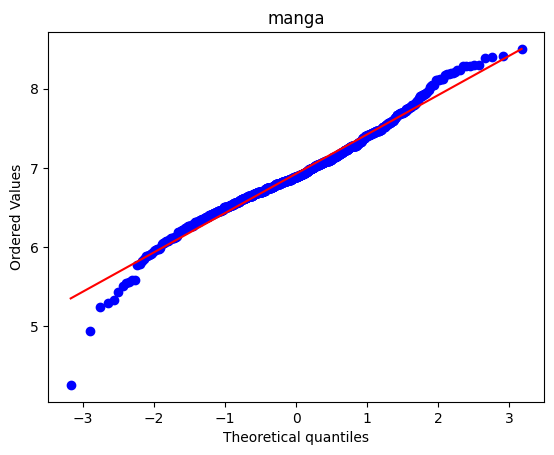

<Figure size 640x480 with 0 Axes>

nan


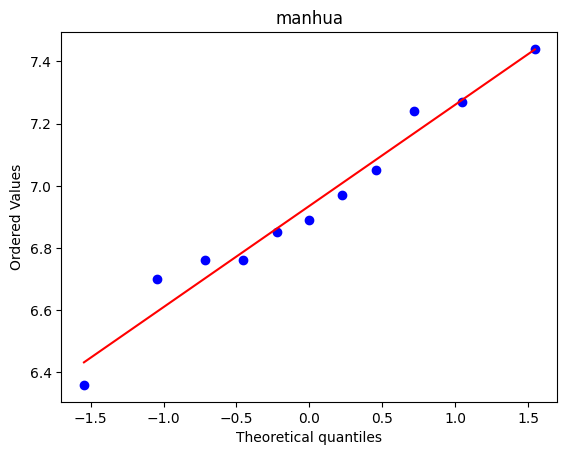

<Figure size 640x480 with 0 Axes>

nan


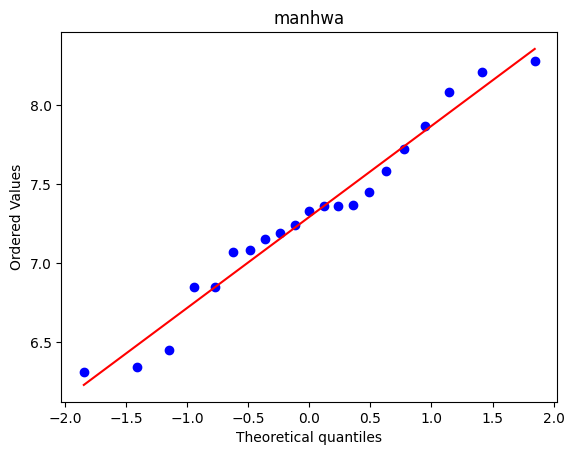

<Figure size 640x480 with 0 Axes>

nan


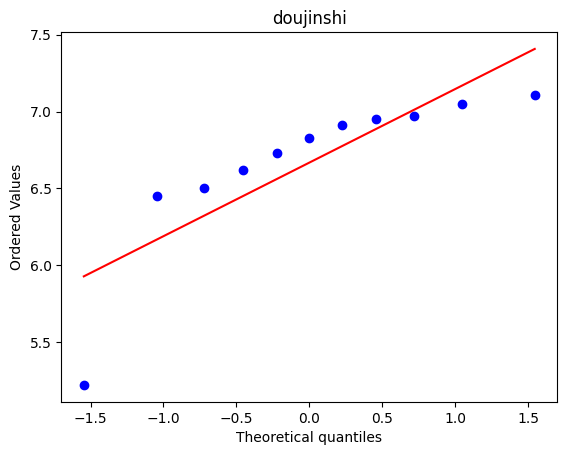

<Figure size 640x480 with 0 Axes>

nan


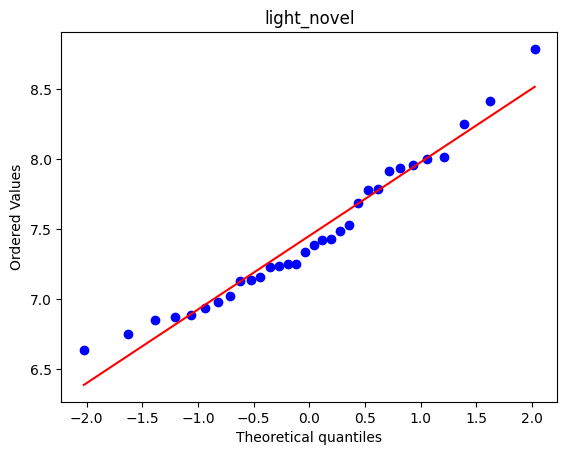

<Figure size 640x480 with 0 Axes>

nan


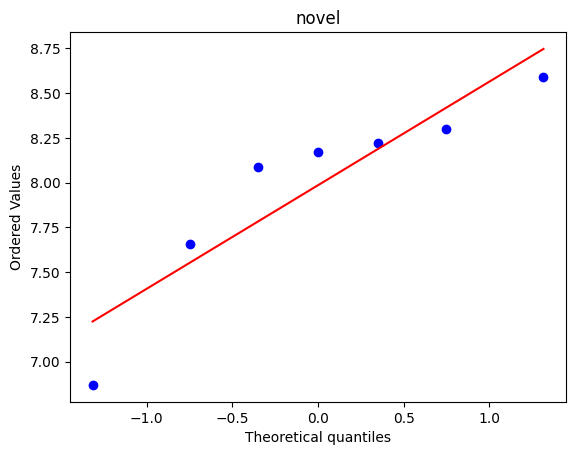

<Figure size 640x480 with 0 Axes>

Levene p-value: 0.68


In [ ]:
print(data['type'].unique())
model = ols(f'score ~ type', data=data).fit()
anova_table = sm.stats.anova_lm(model, type=2)
print(anova_table)

included = data['type']
print(included)
#sns.boxplot(included, showfliers=True)
types = data['type'].unique()
ty_list = []

for ty in types : 
    b, ni = sts.shapiro(data[data['type'] == ty]['score'])
    #c, ne = sts.shapiro(ty)
    
    ty_list.append(data[data['type'] == ty]['score'])
    sts.probplot(data[data['type'] == ty]['score'], plot=plt)
    plt.title(ty)
    plt.figure()
    print(ni)
    #sns.boxplot(excluded, showfliers=True)
    #sts.probplot(excluded, plot=plt)
    #plt.title('excluded ' + title)
    plt.show()
a, si = sts.levene(*ty_list)
print(f'Levene p-value: {si:.2f}')


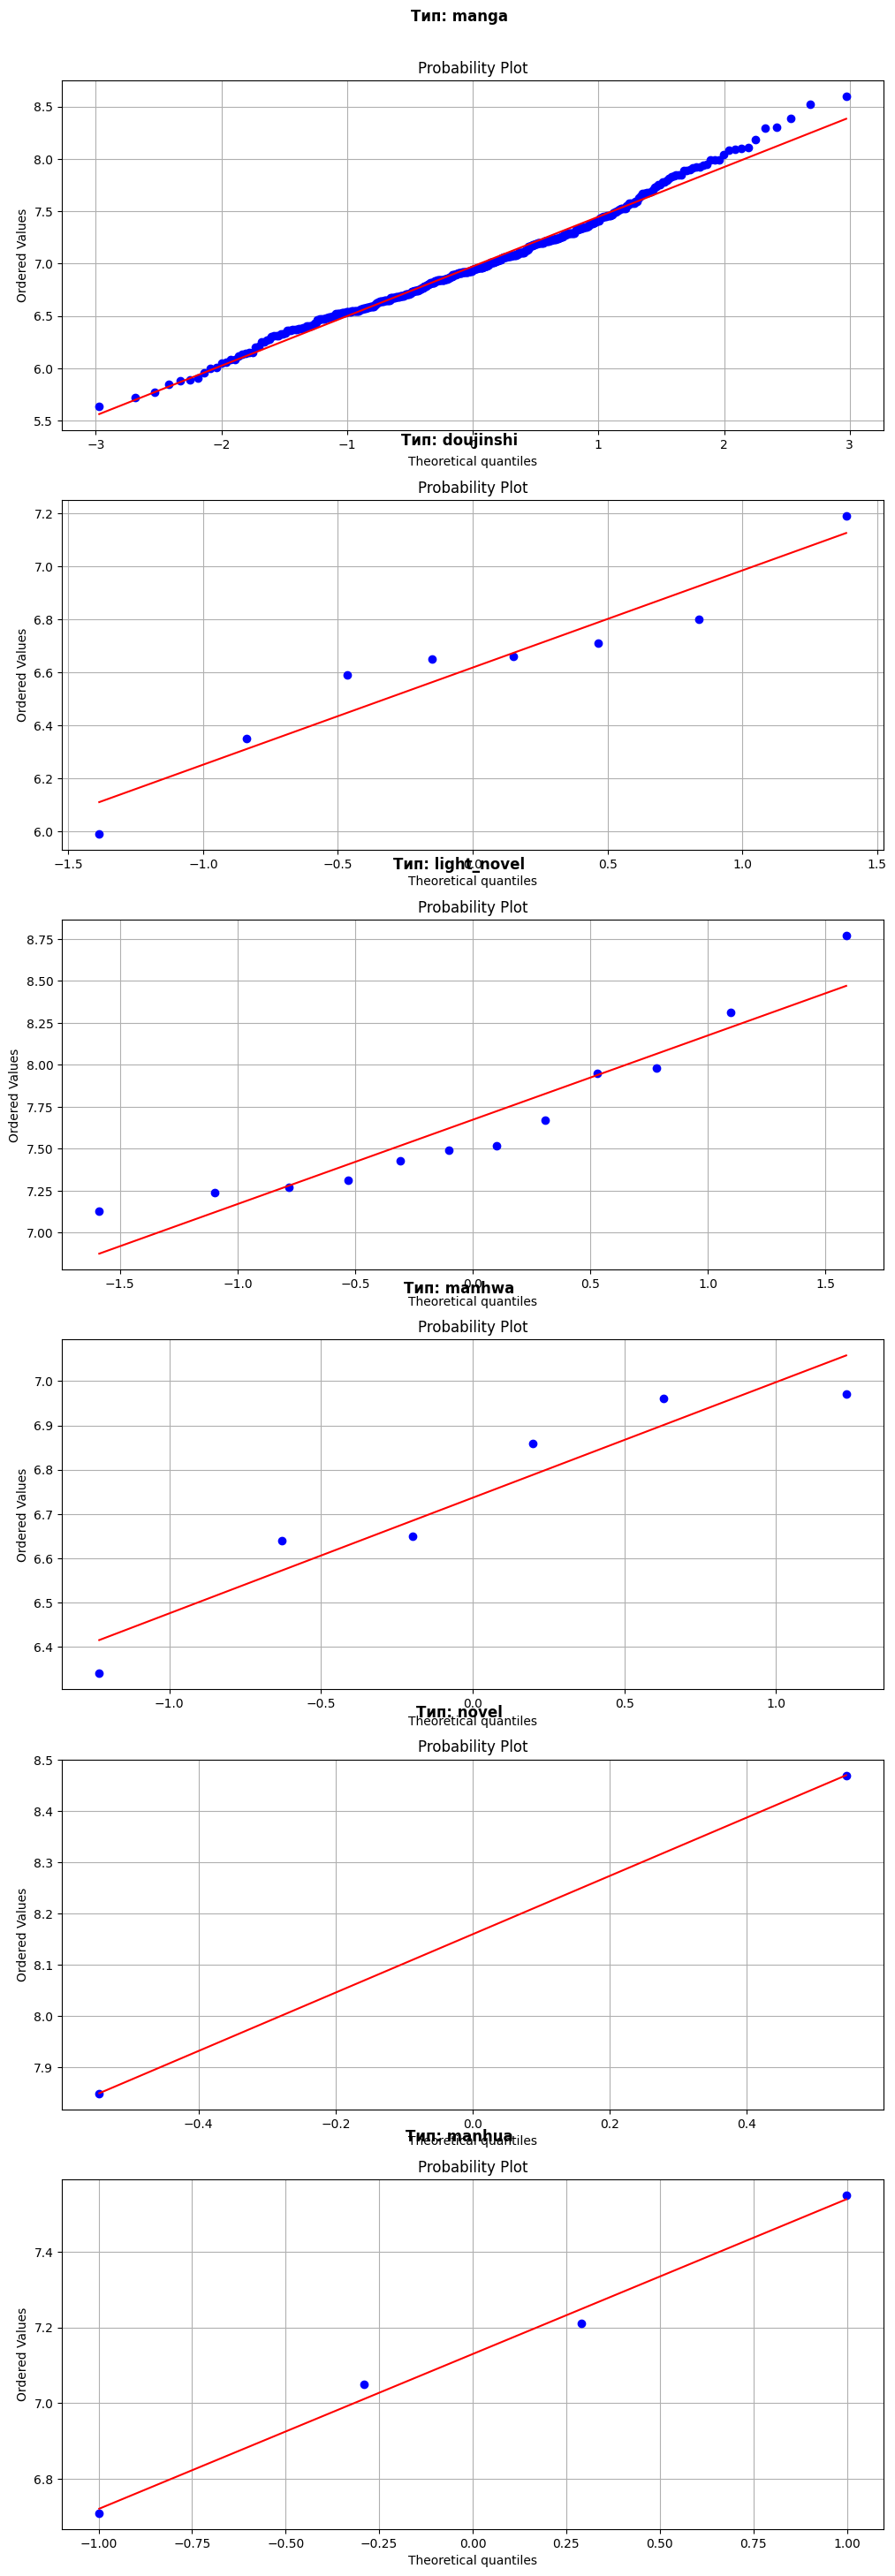

In [ ]:
fig, axes = plt.subplots(len(data['type'].unique()), 1, figsize=(12, 6*len(top_genres)))
i = 0
for dtype in data['type'].unique():

    data_type = data[data[f'type'] == dtype]['score'].dropna()
    
    sts.probplot(data_type, plot=axes[i])  # Используем plot вместо ax
   

    fig.text(
        x=0.5,  # Центрируем по горизонтали
        y=0.9 - i*0.8/len(data['type'].unique()),  # Позиционируем по вертикали
        s=f'Тип: {dtype}',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold'
    )
    
    # Подписи для подграфиков (опционально)
    axes[i].grid(True)
    i += 1
    

/home/baser/DATA/Project/2025/EconometricsAndStatistics/env/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10730: RuntimeWarning: invalid value encountered in scalar divide
  slope = ssxym / ssxm
/home/baser/DATA/Project/2025/EconometricsAndStatistics/env/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10744: RuntimeWarning: invalid value encountered in sqrt
  t = r * np.sqrt(df / ((1.0 - r + TINY)*(1.0 + r + TINY)))
/home/baser/DATA/Project/2025/EconometricsAndStatistics/env/lib/python3.12/site-packages/scipy/stats/_stats_py.py:10750: RuntimeWarning: invalid value encountered in scalar divide
  slope_stderr = np.sqrt((1 - r**2) * ssym / ssxm / df)


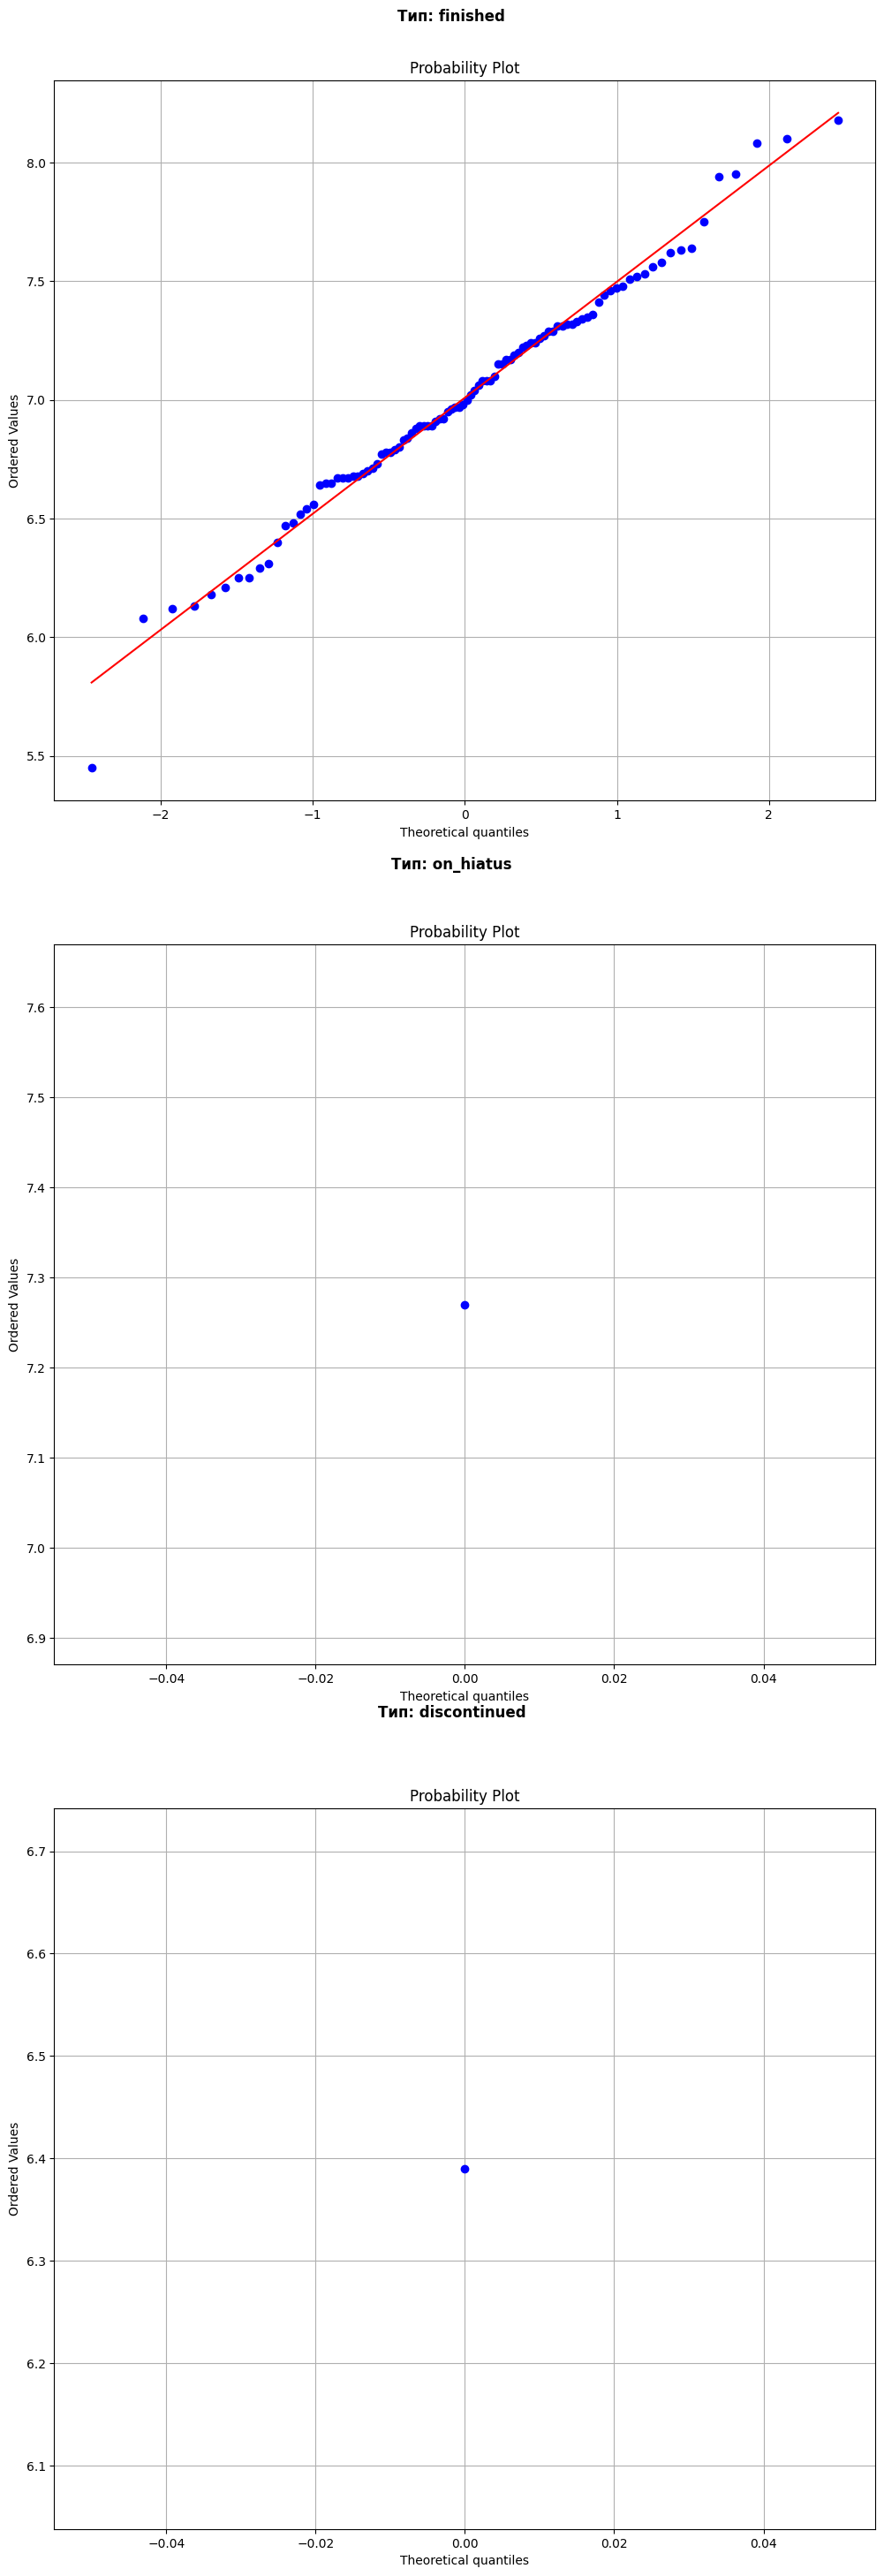

In [ ]:
fig, axes = plt.subplots(len(data['status'].unique()), 1, figsize=(12, 6*len(top_genres)))
i = 0
for dstatus in data['status'].unique():

    data_status = data[data[f'status'] == dstatus]['score'].dropna()
    
    sts.probplot(data_status, plot=axes[i])  # Используем plot вместо ax
   

    fig.text(
        x=0.5,  # Центрируем по горизонтали
        y=0.9 - i*0.8/len(data['status'].unique()),  # Позиционируем по вертикали
        s=f'Тип: {dstatus}',
        ha='center',
        va='center',
        fontsize=12,
        fontweight='bold'
    )
    
    # Подписи для подграфиков (опционально)
    axes[i].grid(True)
    i += 1

2     7.570
6     7.330
9     6.270
11    8.170
12    6.470
       ... 
977   6.690
981   6.960
986   7.390
987   6.900
997   7.760
Name: score, Length: 324, dtype: float64


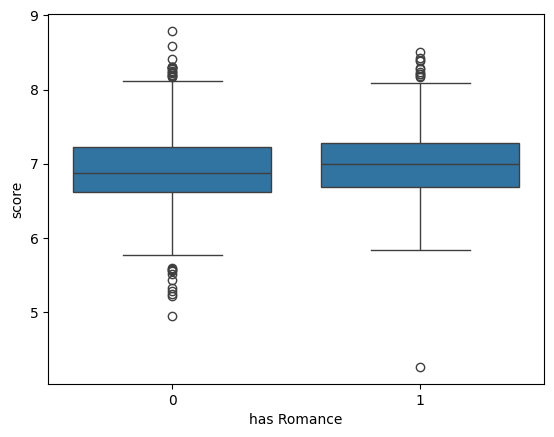

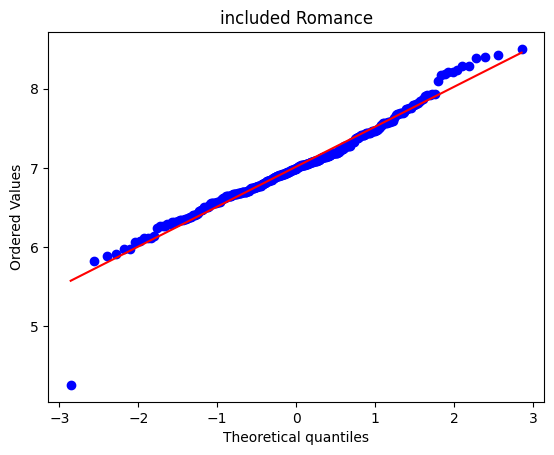

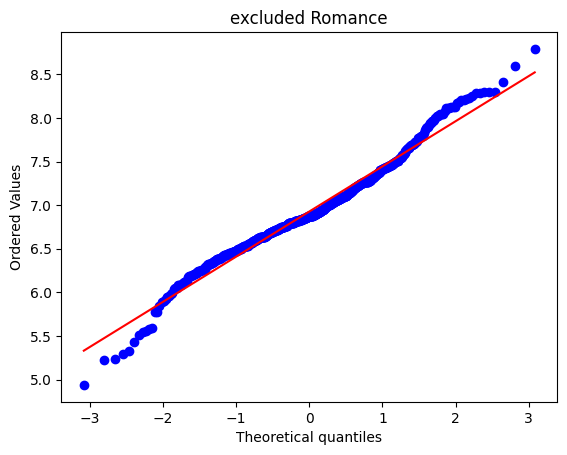

Romance
Levene: 0.8130030606879667
Normality included: 3.352824598845708e-06
Normality excluded: 1.9227218782904785e-08
ttest p-value: 0.013044052263586098
0     6.420
4     6.960
8     6.320
9     6.270
11    8.170
       ... 
977   6.690
981   6.960
983   6.740
993   6.310
996   7.450
Name: score, Length: 270, dtype: float64


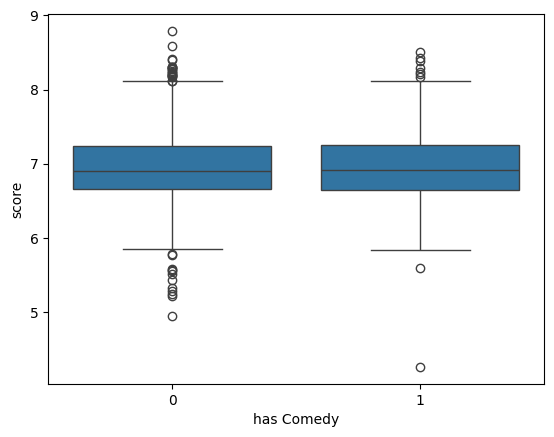

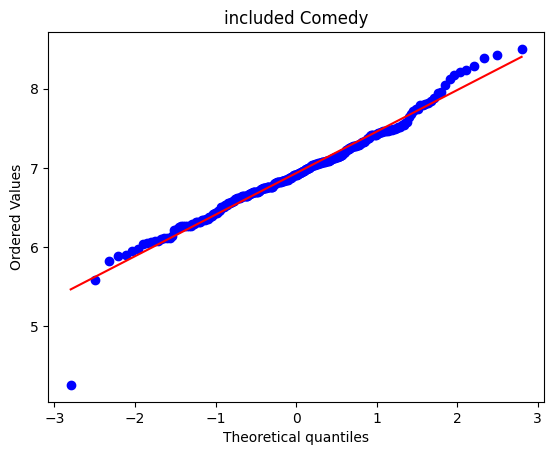

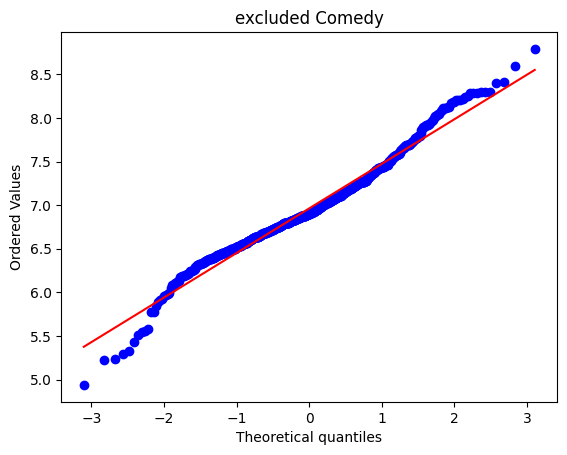

Comedy
Levene: 0.587926557364536
Normality included: 8.521544523319e-05
Normality excluded: 2.5452128448792386e-09
ttest p-value: 0.40919123601614205
1     6.710
7     6.760
22    6.780
25    6.910
52    6.840
       ... 
940   6.550
942   7.150
978   6.900
991   6.950
993   6.310
Name: score, Length: 91, dtype: float64


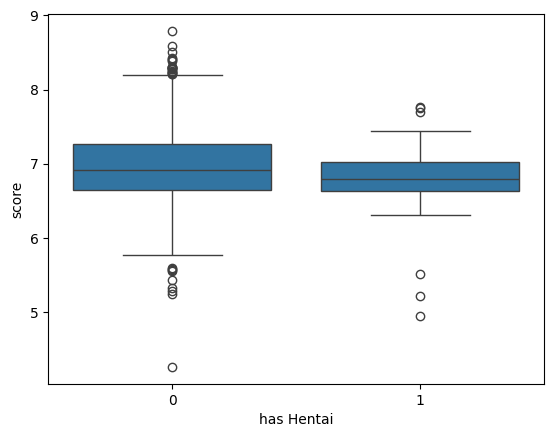

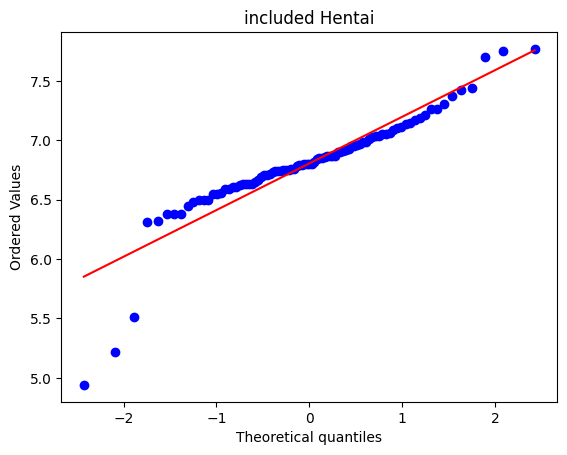

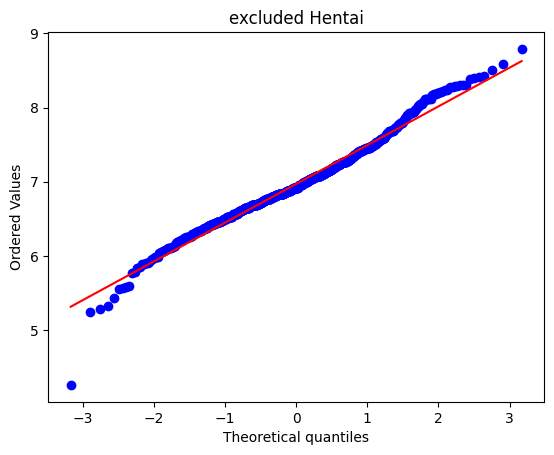

Hentai
Levene: 0.0007620945781187125
Normality included: 1.0958840297938971e-07
Normality excluded: 1.135228356714501e-08
ttest p-value: 0.0038550477781513753
4     6.960
13    6.520
30    6.700
35    6.780
39    6.670
       ... 
965   7.240
970   6.220
971   6.480
972   7.240
995   6.450
Name: score, Length: 128, dtype: float64


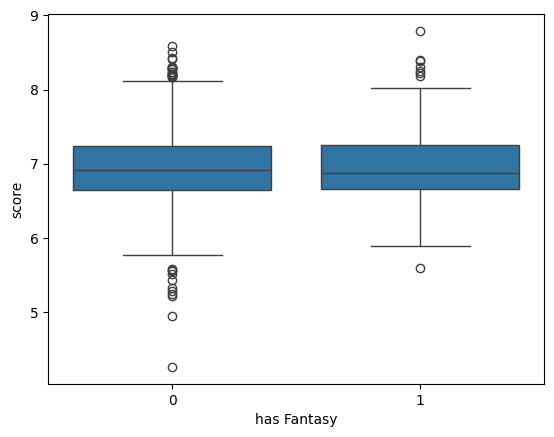

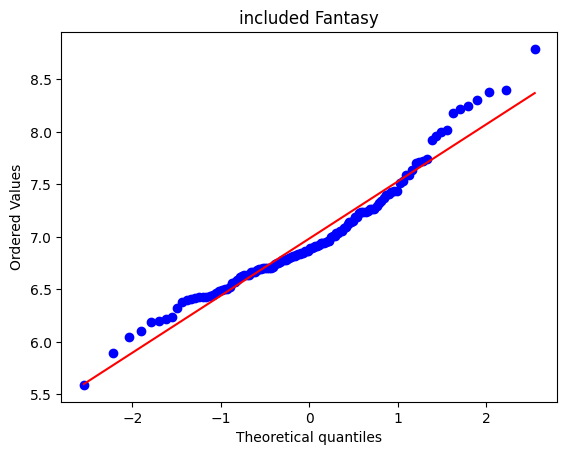

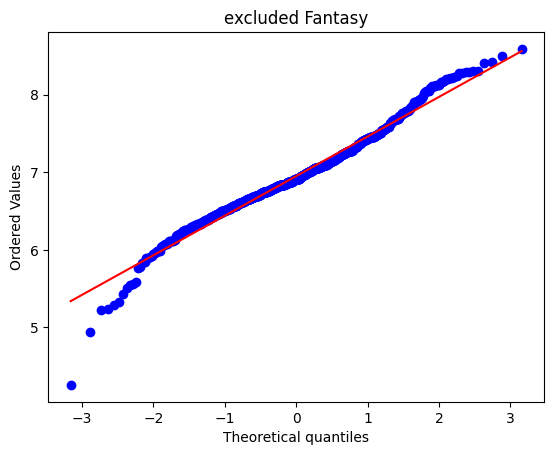

Fantasy
Levene: 0.51785367092815
Normality included: 0.0004469273980619709
Normality excluded: 1.117727190999978e-09
ttest p-value: 0.4997502128125889
2     7.570
3     6.910
18    6.530
19    7.200
28    6.560
       ... 
985   7.430
989   6.600
990   5.990
994   7.090
999   6.530
Name: score, Length: 254, dtype: float64


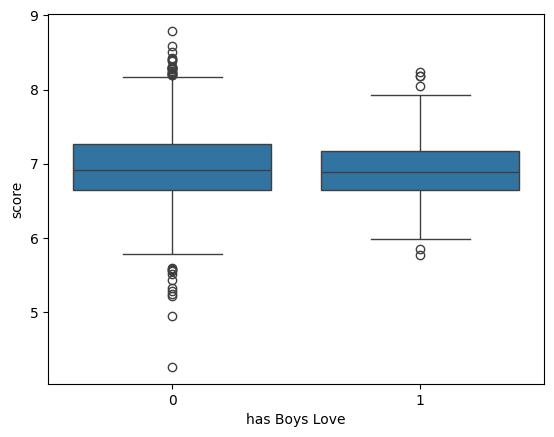

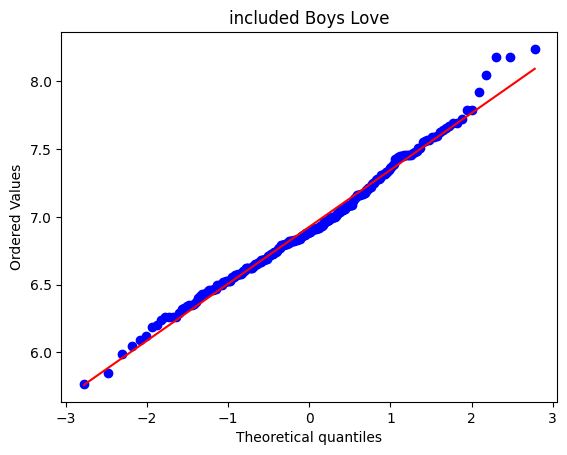

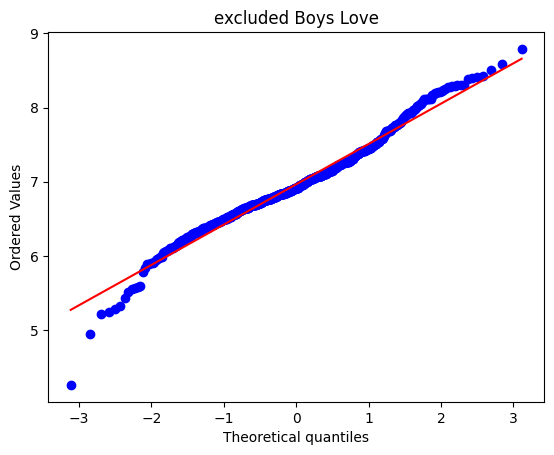

Boys Love
Levene: 0.0006569007827876187
Normality included: 0.06380790312828873
Normality excluded: 4.248787320114352e-09
ttest p-value: 0.31606030136300756
5     6.810
10    6.420
13    6.520
27    6.920
34    7.460
       ... 
980   6.420
981   6.960
985   7.430
986   7.390
994   7.090
Name: score, Length: 209, dtype: float64


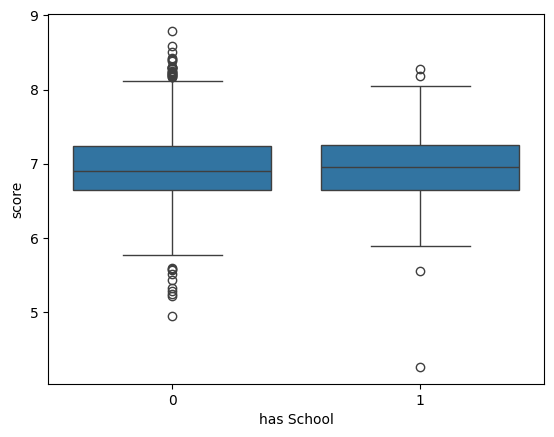

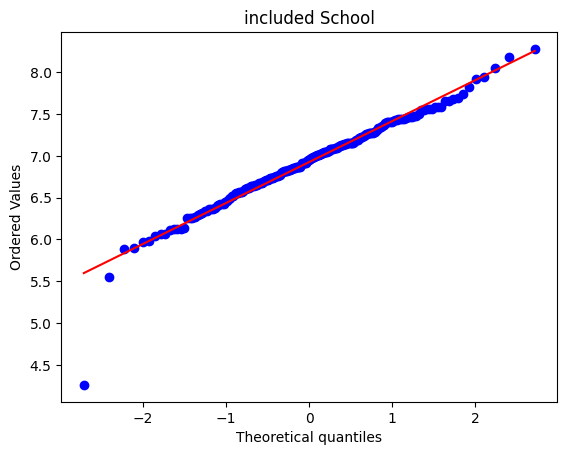

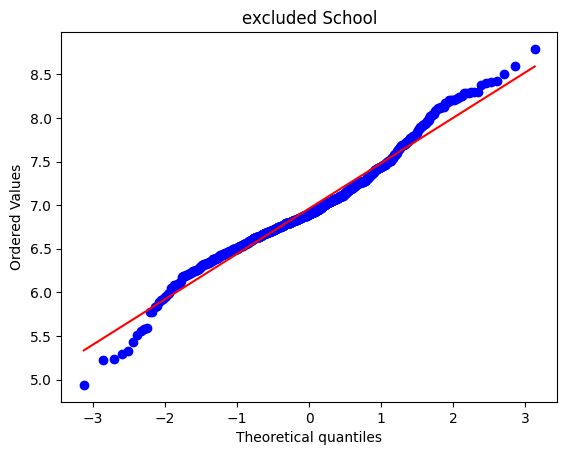

School
Levene: 0.6107680441674548
Normality included: 4.9229570773923594e-05
Normality excluded: 3.7047831380671704e-10
ttest p-value: 0.38680366674686406
7     6.760
28    6.560
71    6.970
87    7.270
99    8.110
115   6.890
122   7.050
164   6.450
181   6.830
198   6.760
207   6.840
225   7.230
232   7.870
237   6.850
244   6.780
262   6.850
263   6.910
265   7.350
306   7.310
315   8.120
364   7.150
430   7.440
549   8.300
554   7.080
562   6.820
578   7.640
647   6.750
683   7.300
716   6.940
720   6.780
728   7.900
782   7.230
791   6.340
804   7.720
849   6.620
857   6.530
869   7.540
875   6.440
907   6.690
952   6.830
997   7.760
Name: score, dtype: float64


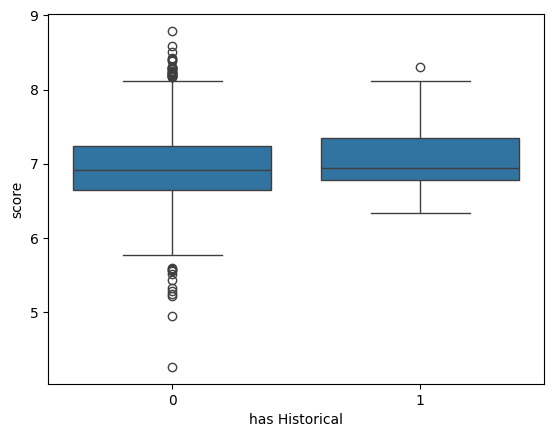

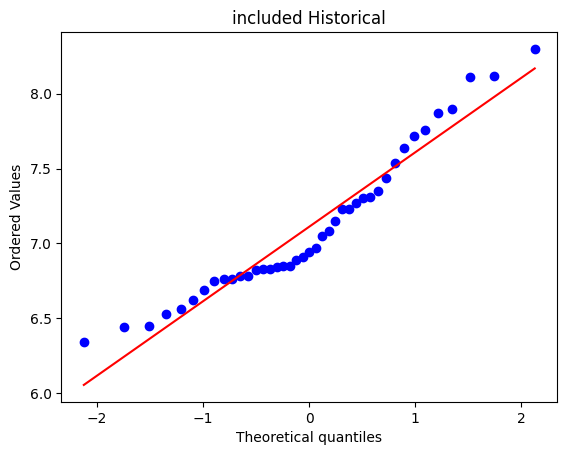

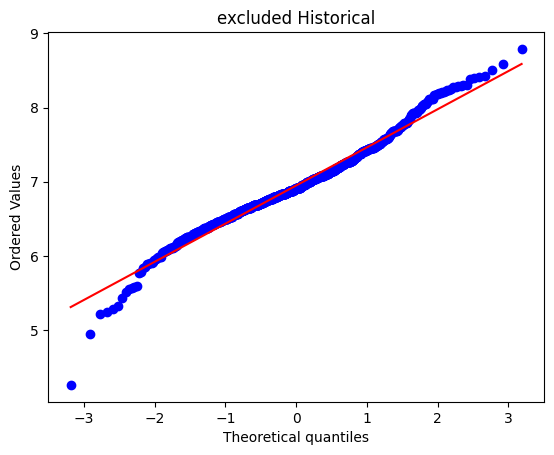

Historical
Levene: 0.9533548059053524
Normality included: 0.021192128174695606
Normality excluded: 1.9155687347149063e-10
ttest p-value: 0.049059936716494404
45    6.690
52    6.840
81    7.400
142   6.740
187   7.410
195   7.150
231   7.510
278   5.550
282   6.870
292   6.590
294   7.440
342   7.280
357   7.310
517   7.190
593   7.490
600   6.940
628   6.940
633   7.480
671   7.030
676   7.170
718   6.950
776   6.890
808   7.800
817   7.250
836   7.410
903   5.890
921   6.290
932   6.870
961   7.020
991   6.950
995   6.450
Name: score, dtype: float64


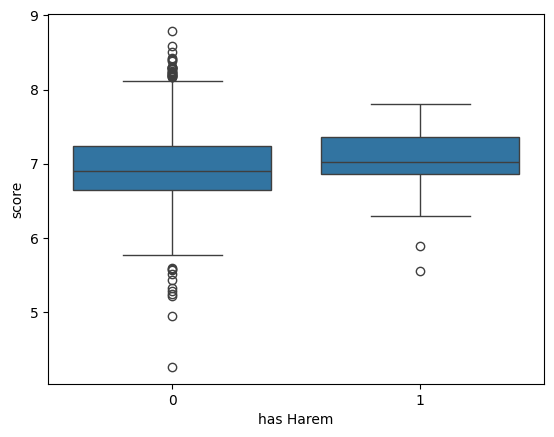

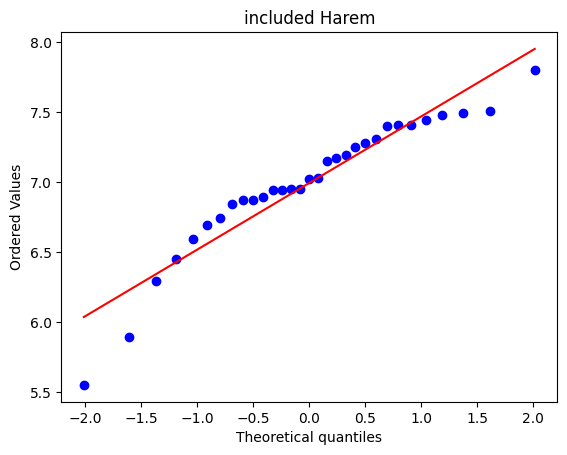

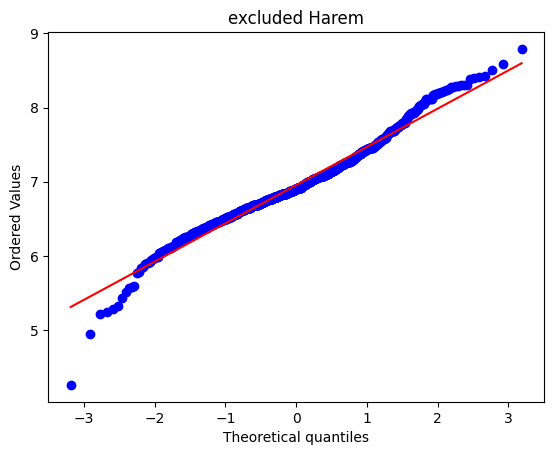

Harem
Levene: 0.5420671684968814
Normality included: 0.02072328070919698
Normality excluded: 4.31926061388393e-11
ttest p-value: 0.6776293586419444
5     6.810
14    7.080
29    8.210
70    7.130
78    5.780
101   7.510
154   7.400
163   7.070
167   8.000
172   8.200
201   7.440
208   6.570
257   6.080
334   8.280
351   6.610
373   7.160
399   6.740
400   8.280
402   6.320
421   7.550
457   7.040
459   7.020
477   6.850
505   7.080
529   7.250
535   6.520
538   8.290
540   7.690
555   6.690
565   6.980
602   6.190
615   6.210
653   6.530
671   7.030
746   6.680
777   7.740
791   6.340
793   6.560
800   7.770
846   7.710
900   8.300
951   6.110
967   6.970
984   7.400
985   7.430
994   7.090
998   7.020
Name: score, dtype: float64


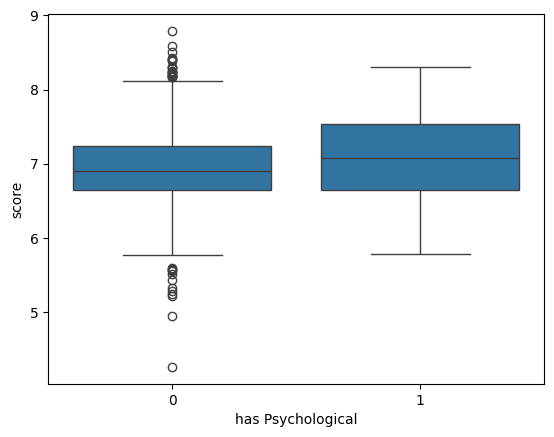

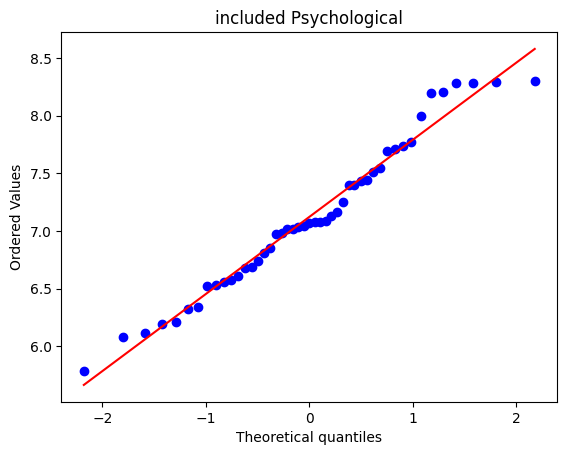

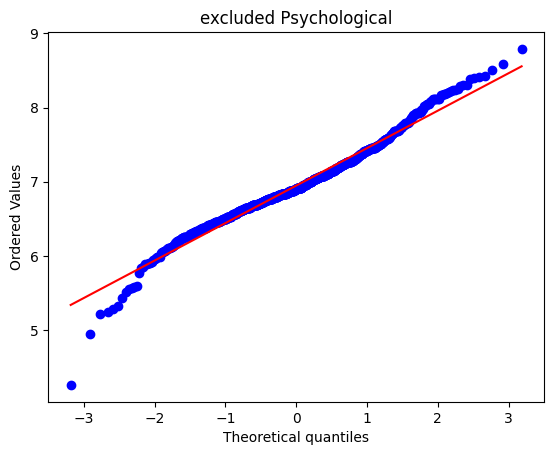

Psychological
Levene: 0.008020831325903937
Normality included: 0.21355652569251565
Normality excluded: 8.083366411892164e-11
ttest p-value: 0.024229116701564156
223   6.560
259   5.590
501   6.810
722   6.690
763   6.640
777   7.740
918   8.790
Name: score, dtype: float64


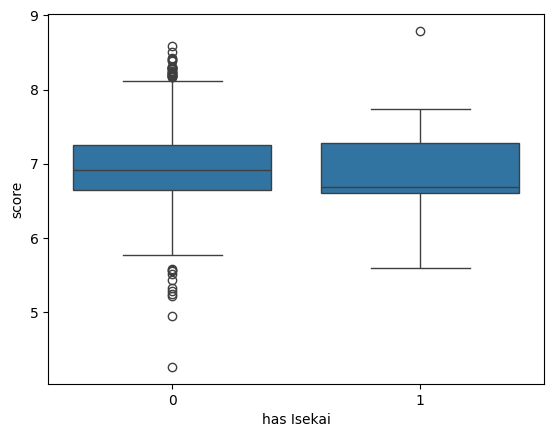

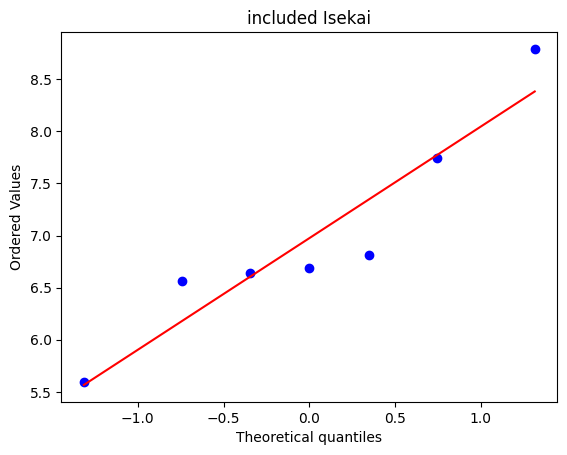

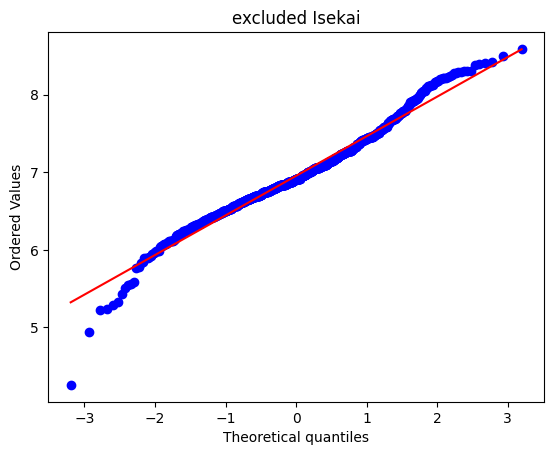

Isekai
Levene: 0.045641108468415334
Normality included: 0.40667313628671725
Normality excluded: 9.86856279334098e-11
ttest p-value: 0.9216990229600858


In [56]:
def perform_ttest(included, excluded, title) :
    print(included)
    plt.figure()

    sns.boxplot(y = data['score'], x = data[f'has {title}'], showfliers=True)

    a, si = sts.levene(included, excluded)
    b, ni = sts.shapiro(included)
    c, ne = sts.shapiro(excluded)
    plt.figure()
    sts.probplot(included, plot=plt)
    plt.title('included ' + title)
    plt.figure()
    sts.probplot(excluded, plot=plt)
    plt.title('excluded ' + title)
    plt.show()

    d, tt = sts.ttest_ind(included, excluded)

    print(title, 'Levene: ' + str(si), "Normality included: " + str(ni), "Normality excluded: " + str(ne), 'ttest p-value: ' + str(tt), sep="\n")



for genre in top_genres :
    
    inc = data[data[f'has {genre}'] == 1]['score']
    exc = data[data[f'has {genre}'] == 0]['score']

    perform_ttest(inc, exc, genre)

for theme in top_themes :
    inc = data[data[f'has {theme}'] == 1]['score']
    exc = data[data[f'has {theme}'] == 0]['score']
    perform_ttest(inc, exc, theme)
